This is part 1 of a tutorial series. We recommend following them in order, starting with [Part 0: Welcome to `musica`](0.%20Welcome%20to%20MUSICA.ipynb).

# Multiple Grid Cells in `musica`

As we saw in the last tutorial, gas-phase systems can be solved in `musica` using a `solver` and a `state`. For box models, that's all we need. For more complex applications (columns, 3D grids, etc.), we'll need to manage the state of a number of independent well-mixed air masses, or "grid cells".

>__NOTE:__ We use "grid cell" throughout these tutorials to mean a well-mixed air mass. A vertical stack of "grid cells" would be used for a column-model. Collections of vertical stacks of grid cells would be used for a 3D grid or mesh. However, `micm` does not make assumptions about the shape, size, or arragement of the well-mixed air mass(es) a `state` represents, so the state can be used to represent air masses of any size/shape in any arrangement.

_Why multiple grid cell states?_

If we can create as many states as we want and use the same solver on them, maybe you're wondering why we even need multiple-grid-cell states. The answer, once again, is for performance. In HPC applications, `micm` can be used to solve hundreds of thousands of independent grid cells simultaneously. To do this efficiently, the data needs to be efficiently arranaged in memory. Multiple-grid-cell states allow us to do this.

## 1. Importing Libraries
Below is a list of the required libraries for this tutorial:

In [1]:
import musica
import musica.mechanism_configuration as mc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
pd.set_option('display.float_format', str) # This is done to make the arrays more readable
np.set_printoptions(suppress=True) # This is done to make the arrays more readable

## 2. Defining a System

In the first tutorial, we used an example configuration file to define our chemical system. This time, we'll use the `musica` API to define a chemical system in code. We'll use this apporach for future tutorials as well.

Let's set up a system analogous to the simple analytically solvable system we used in the first tutorial

In [2]:
A = mc.Species(name="A")
B = mc.Species(name="B")
C = mc.Species(name="C")
species = [A, B, C]
gas = mc.Phase(name="gas", species=species)

r1 = mc.Arrhenius(
    name="A_to_B",
    A=4.0e-3,
    C=50,
    reactants=[A],
    products=[B],
    gas_phase=gas
)

r2 = mc.Arrhenius(
    name="B_to_C",
    A=4.0e-3,
    C=50,  
    reactants=[B],
    products=[C],
    gas_phase=gas
)

Similar to the last tutorial, we have defined a simple system with:
* Three species (`A`, `B`, and `C`) in the gas-phase
* Two Arrhenius reactions
    * `A -> B`
    * `B -> C`

We try to keep the python API consistent with the format of the configuration files, and have both structured around the science.

The documentation can be used to clarify important details, like the parameter names and units for rate constant types

In [3]:
mc.Arrhenius?

In the last chapter, we used the `musica` parser to turn our configuration file into a `mechanism`. Here, we'll create the mechanism out of the chemistry objects we've defined above

In [4]:
mechanism = mc.Mechanism(
    name="musica_micm_example",
    species=species,
    phases=[gas],
    reactions=[r1, r2]
)
for reaction in mechanism.reactions:
    print(f"[{reaction.type.name}] {reaction.to_equation()}")

[Arrhenius] A -> B
[Arrhenius] B -> C


## 3. Creating the Solver

We create a solver for our `mechanism` the same way we did in the last tutorial.
One minor difference here, is that we specifcy the `solver_type`.
For more information on the types of solvers available, see [here](https://ncar.github.io/micm/user_guide/solver_configurations.html).
The standard-ordered Rosenbrock solver is actually the default `solver_type`, so including it here has no real effect.

>__NOTE:__ If you're wondering what "standard order" means, it refers to how the matrix data in the `state` in arranged in memory. `micm` is designed to be performant enough to be included in large-scale climate and weather models. To achieve optimal performance we have advanced matrix ordering strategies we can apply to encourage vectorization of the solver instructions. For most Python-based applications, the standard ordering will be sufficient.

In [5]:
solver = musica.MICM(mechanism = mechanism, solver_type = musica.SolverType.rosenbrock_standard_order)

## 4. Creating the State

In the last tutorial, we created a single-grid-cell `state`. This time, let's double the complexity of our system and create a two-grid-cell `state`!

In [6]:
num_grid_cells = 2
state = solver.create_state(num_grid_cells)

## 5. Setting Conditions

Next, let's set the conditions for our two-grid-cell state. In the last tutorial, you may have wondered why the temperature, pressure, and species concentrations were in array format. Hopefully, now it's clear - one element for each grid cell!

In [7]:
state.set_conditions(temperatures=[300, 100], pressures=[101253.3, 11253.3])
state.set_concentrations({
    'A': [5, 20],
    'B': [5, 3],
    'C': [5, 7]
})

## 7. Solving the System

This time around, we'll advance the state for 60 s, collecting intermediate states each second.

In [8]:
concentrations_solved = []
time_step = 10 # s
sim_length = 600 # s
curr_time = 0 # s
while curr_time <= sim_length:
    solver.solve(state, time_step)
    concentrations_solved.append(state.get_concentrations())
    curr_time += time_step

## 8. Preparing the Results (Advanced; Optional Read)

We're going to create a short helper function to put the results into a Pandas DataFrame for easier plotting.
The function will extract results for a single grid cell, and we call it twice, once for each of the grid cells in our `state`.
In this simulation, the temperature, pressure, and air density are all constant, so numpy's `repeat()` function is used to repeat their respective values for every time step.

In [9]:
def convert_results_single_cell(cell_index):
    concentrations_solved_pd = []
    for i in range(0, sim_length + 1, time_step):
        concentrations_solved_pd.append({species: concentration[cell_index] for species, concentration in concentrations_solved[int(i/time_step)].items()})
    df = pd.DataFrame(concentrations_solved_pd)
    df = df.rename(columns = {'A' : 'CONC.A.mol m-3', 'B' : 'CONC.B.mol m-3', 'C' : 'CONC.C.mol m-3'})
    df['time.s'] = list(map(float, range(0, sim_length + 1, time_step)))
    df['ENV.temperature.K'] = np.repeat(state.get_conditions()['temperature'][cell_index], sim_length/time_step + 1.0)
    df['ENV.pressure.Pa'] = np.repeat(state.get_conditions()['pressure'][cell_index], sim_length/time_step + 1.0)
    df['ENV.air number density.mol m-3'] = np.repeat(state.get_conditions()['air_density'][cell_index], sim_length/time_step + 1.0)
    df = df[['time.s', 'ENV.temperature.K', 'ENV.pressure.Pa', 'ENV.air number density.mol m-3', 'CONC.A.mol m-3', 'CONC.B.mol m-3', 'CONC.C.mol m-3']]
    return df

In [10]:
df_0 = convert_results_single_cell(0)
df_1 = convert_results_single_cell(1)

## 9. Viewing the Results

Finally, let's desplay and plot the DataFrames to show the evolution of both of the independent systems over time.

,time.s,ENV.temperature.K,ENV.pressure.Pa,ENV.air number density.mol m-3,CONC.A.mol m-3,CONC.B.mol m-3,CONC.C.mol m-3
0,0.0,300.0,101253.3,40.59324282282551,4.76922334303805,4.994590692532435,5.236185964429513
1,10.0,300.0,101253.3,40.59324282282551,4.549098259155805,4.9790291487427,5.471872592101488
2,20.0,300.0,101253.3,40.59324282282551,4.339133121467923,4.954264051821206,5.706602826710863
3,30.0,300.0,101253.3,40.59324282282551,4.138858994290876,4.921178138841699,5.939962866867419
4,40.0,300.0,101253.3,40.59324282282551,3.9478285858230064,4.8805922672973425,6.171579146879646
...,...,...,...,...,...,...,...
56,560.0,300.0,101253.3,40.59324282282551,0.3382177774161425,1.2492099030181651,13.412572319565694
57,570.0,300.0,101253.3,40.59324282282551,0.32260722381670276,1.2067968547753385,13.470595921407961
58,580.0,300.0,101253.3,40.59324282282551,0.3077171804918639,1.1656377730117506,13.526645046496386
59,590.0,300.0,101253.3,40.59324282282551,0.29351439205113017,1.1257072563871726,13.580778351561698


,time.s,ENV.temperature.K,ENV.pressure.Pa,ENV.air number density.mol m-3,CONC.A.mol m-3,CONC.B.mol m-3,CONC.C.mol m-3
0,0.0,100.0,11253.3,13.53460893002309,18.72357316215889,4.04334124172365,7.233085596117464
1,10.0,100.0,11253.3,13.53460893002309,17.528609597935834,4.941288116208338,7.530102285855836
2,20.0,100.0,11253.3,13.53460893002309,16.40991021189361,5.708149451042962,7.881940337063443
3,30.0,100.0,11253.3,13.53460893002309,15.362607721842412,6.356999871717215,8.28039240644039
4,40.0,100.0,11253.3,13.53460893002309,14.382145482073177,6.899779056293003,8.718075461633836
...,...,...,...,...,...,...,...
56,560.0,100.0,11253.3,13.53460893002309,0.4660987829533735,1.822029649269642,27.711871567777017
57,570.0,100.0,11253.3,13.53460893002309,0.4363517331710352,1.7345223337021152,27.829125933126896
58,580.0,100.0,11253.3,13.53460893002309,0.4085031800231355,1.6507632617514378,27.940733558225475
59,590.0,100.0,11253.3,13.53460893002309,0.38243195890688714,1.5706304291624618,28.046937611930705


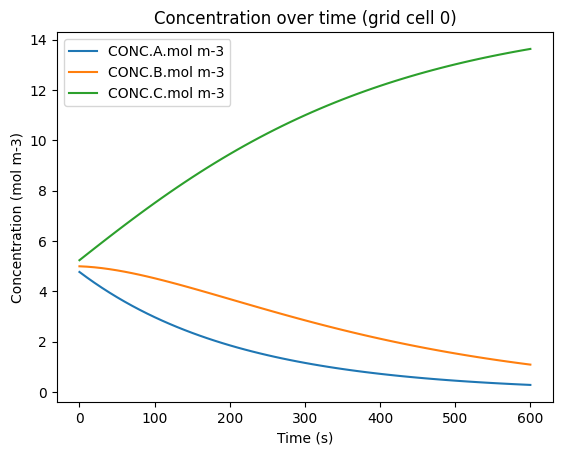

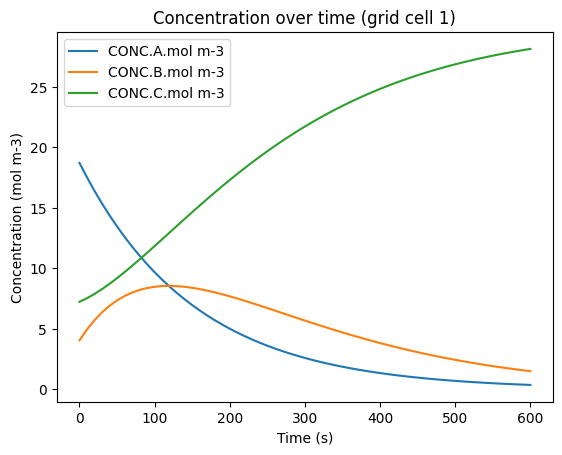

In [11]:
display(df_0)
display(df_1)
df_0.plot(x='time.s', y=['CONC.A.mol m-3', 'CONC.B.mol m-3', 'CONC.C.mol m-3'], title='Concentration over time (grid cell 0)', ylabel='Concentration (mol m-3)', xlabel='Time (s)')
df_1.plot(x='time.s', y=['CONC.A.mol m-3', 'CONC.B.mol m-3', 'CONC.C.mol m-3'], title='Concentration over time (grid cell 1)', ylabel='Concentration (mol m-3)', xlabel='Time (s)')
plt.show()

## 10. Going Full Circle

We've now seen the two ways to configure `musica` in practice: using configuration files, and in-code using the `musica` API. What if we want to create a configuration code from our in-code mechanism?

Let's give it a try!

In [12]:
mechanism.export("my_cool_musica_mechanism.json")

Let's take a look at what it looks like

In [13]:
import json

with open("my_cool_musica_mechanism.json", "r") as f:
    config = json.load(f)

print(json.dumps(config, indent=2))

{
  "name": "musica_micm_example",
  "reactions": [
    {
      "type": "ARRHENIUS",
      "name": "A_to_B",
      "A": 0.004,
      "B": 0.0,
      "C": 50.0,
      "D": 300.0,
      "E": 0.0,
      "reactants": [
        {
          "species name": "A",
          "coefficient": 1.0
        }
      ],
      "products": [
        {
          "species name": "B",
          "coefficient": 1.0
        }
      ],
      "gas phase": "gas"
    },
    {
      "type": "ARRHENIUS",
      "name": "B_to_C",
      "A": 0.004,
      "B": 0.0,
      "C": 50.0,
      "D": 300.0,
      "E": 0.0,
      "reactants": [
        {
          "species name": "B",
          "coefficient": 1.0
        }
      ],
      "products": [
        {
          "species name": "C",
          "coefficient": 1.0
        }
      ],
      "gas phase": "gas"
    }
  ],
  "species": [
    {
      "name": "A",
      "is third body": false
    },
    {
      "name": "B",
      "is third body": false
    },
    {
      "name": "

Why is this useful? The `musica` library than underpins the `musica` python package is also used in large 3D models. For those applications, text-based configuration files allow run-time specification of the chemistry system without the need to modify source code and recompile the models. So, you can develop and test your mechanism in Python and when you're ready, turn it into a configuration file that you can use in a model like CheMPAS-A or CAM-SIMA!